In [ ]:
# precisei baixar o imgaug separado pq tava danco conflito
!pip install imgaug

In [ ]:
from torchvision import datasets # importa datasets prontos
import torch # biblioteca base do PyTorch
from torch.utils.data import Dataset, DataLoader # ferramentas para organizar os dados
import torch.nn as nn # modulo de construção de camadas
import matplotlib.pyplot as plt # biblioteca para plotar graficos
%matplotlib inline
import numpy as np # biblioteca para calculos
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
data_folder = './content' # pasta dos dados

fmnist = datasets.FashionMNIST(data_folder, download=True, train=True) # baixa e carrega os dados

tr_images = fmnist.data # srmazena as imagens
tr_targets = fmnist.targets # Armazena os rotulos
val_fmnist = datasets.FashionMNIST(data_folder, download=True, train=False) # baixa e carrega os dados

val_images = val_fmnist.data # armazena as imagens de teste
val_targets = val_fmnist.targets # armazena os rótulos de teste

In [ ]:
import albumentations as iaa

# Utilizamos esse pacote para realizar data augmentation
aug = iaa.Compose([
    iaa.Affine(translate_px={'x': (-10, 10), 'y': (0, 0)},
             mode=0, p=1.0)
])

/tmp/ipykernel_5964/4175985745.py:5: UserWarning: Argument(s) 'mode' are not valid for transform Affine
  iaa.Affine(translate_px={'x': (-10, 10), 'y': (0, 0)},


In [ ]:
class FMNISTDataset(Dataset): # cria a classe
    def __init__(self, x, y, aug=None): # inicializa a classe com imagens
        self.x, self.y = x, y # salva as imagens e os rotulos
        self.aug = aug # salva as configuraçoes
    def __getitem__(self, ix): # função para pegar um item
        x, y = self.x[ix], self.y[ix] # busca a imagem e o rótulo
        return x, y # retorna a imagem e rotulo
    def __len__(self): return len(self.x) # retorna a quantidade

    def collate_fn(self, batch): # função para processar
        'logic to modify a batch of images'
        ims, classes = list(zip(*batch)) # separa em listas
        if self.aug: # verifica o aumento de dados para aplicar
            ims_np = np.array([tensor.numpy() for tensor in ims]) # converte tensores para numpy

        ims = torch.tensor(ims)[:, None, :, :].to(device)/255. # transforma em tensor
        classes = torch.tensor(classes).to(device) # converte rotulos para tensor
        return ims, classes # retorna o lote processado para o treino

In [ ]:
from torch.optim import SGD, Adam # importa os otimizadores

def get_model(): # cria a sequência de camadas da rede neural
    model = nn.Sequential(
        nn.Conv2d(1, 64, kernel_size=3),
        nn.MaxPool2d(2),
        nn.Conv2d(64, 128, kernel_size=3),
        nn.MaxPool2d(2),
        nn.ReLU(),
        nn.Flatten(),
        nn.Linear(3200, 256),
        nn.ReLU(),
        nn.Linear(256, 10)
    ).to(device)

    loss_fn = nn.CrossEntropyLoss() # função de erro para classificação
    optimizer = Adam(model.parameters(), lr=1e-3) # otimizador Adam

    return model, loss_fn, optimizer # retorna o modelo

In [ ]:
def train_batch(x, y, model, opt, loss_fn):
    model.train() # coloca o modelo em modo de treinamento
    prediction = model(x) # faz a previsão
    batch_loss = loss_fn(prediction, y) # calcula o erro comparando
    batch_loss.backward() # faz o backpropagation
    opt.step() # o otimizador atualiza os pesos
    opt.zero_grad() # limpa os gradientes
    return batch_loss.item() # retorna o valor

In [ ]:
def get_data():
    # cria o dataset de treino
    train = FMNISTDataset(tr_images, tr_targets, aug=aug)
    'notice the collate_fn argument'
    trn_dl = DataLoader(train, batch_size=64, # carrega o treino em lote
                        collate_fn=train.collate_fn, shuffle=True)
    val = FMNISTDataset(val_images, val_targets) # cria o dataset de validação
    val_dl = DataLoader(val, batch_size=len(val_images), # carrega a validação
                        collate_fn=val.collate_fn, shuffle=True)
    return trn_dl, val_dl # retorna os carregadore

In [ ]:
trn_dl, val_dl = get_data()
model, loss_fn, optimizer = get_model()
for epoch in range(5):
    print(epoch) # imprime o número da época
    for ix, batch in enumerate(iter(trn_dl)):
        x, y = batch  # o lote de dados
        batch_loss = train_batch(x, y, model, optimizer, loss_fn)

0


/tmp/ipykernel_5964/180090311.py:24: UserWarning: Creating a tensor from a list of numpy.ndarrays is extremely slow. Please consider converting the list to a single numpy.ndarray with numpy.array() before converting to a tensor. (Triggered internally at /pytorch/torch/csrc/utils/tensor_new.cpp:253.)
  ims = torch.tensor(ims)[:, None, :, :].to(device)/255. # transforma em tensor


1
2
3
4


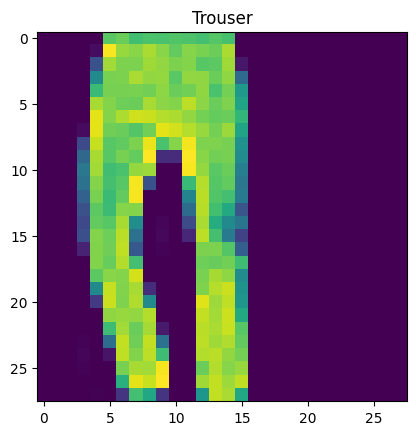

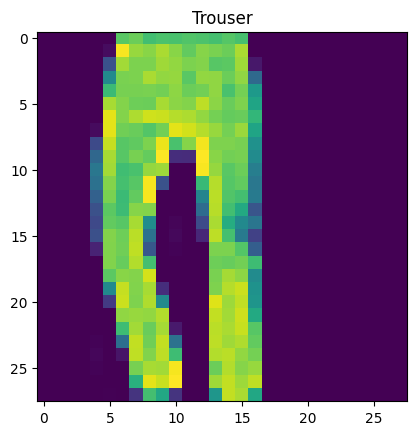

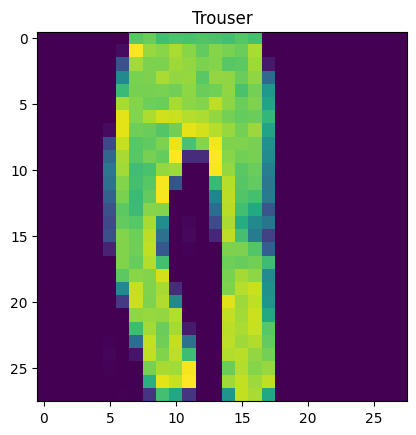

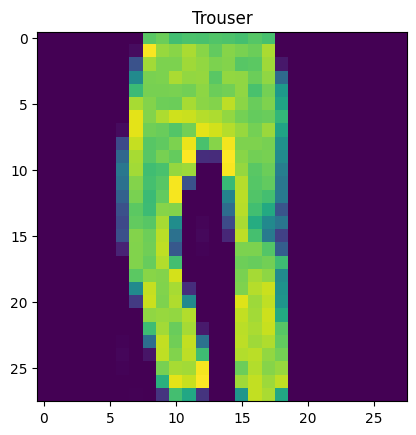

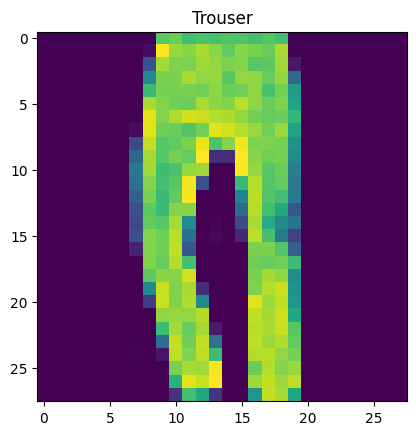

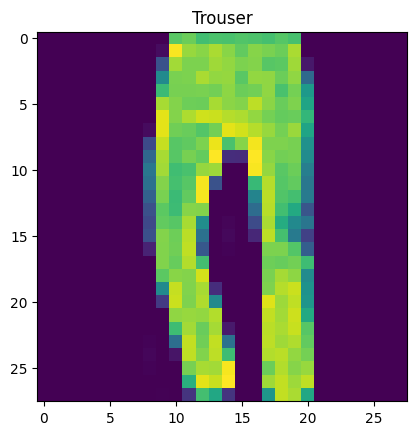

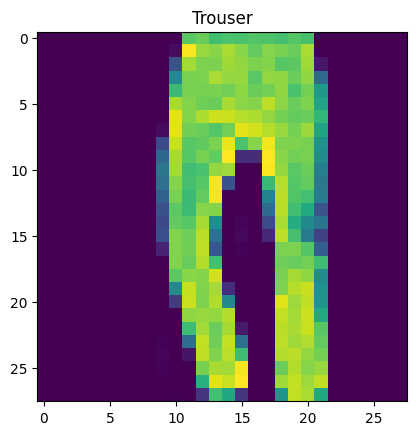

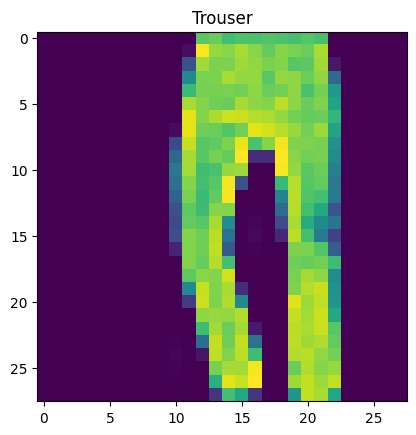

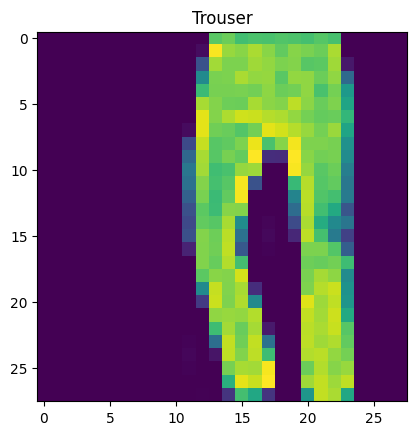

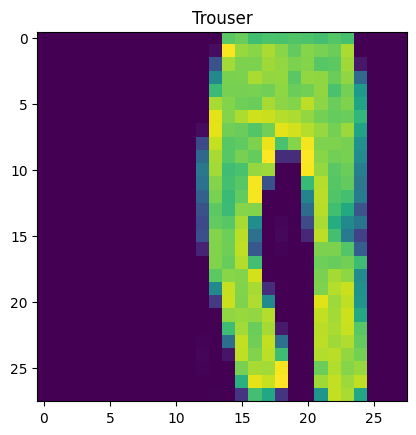

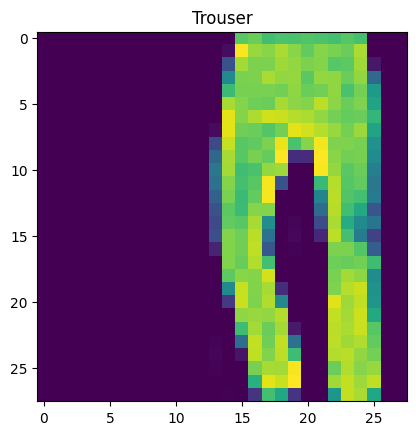

In [ ]:
preds = [] # cria uma lista
ix = 24300 # define o índice
for px in range(-5, 6): # faz um loop para deslocar a imagem
    img = tr_images[ix]/255.
    img = img.view(28, 28)
    img2 = np.roll(img, px, axis=1)
    img3 = torch.Tensor(img2).view(-1, 1, 28, 28).to(device) # converte para tensor
    np_output = model(img3).cpu().detach().numpy() # passa a imagem pelo modelo
    pred = np.exp(np_output)/np.sum(np.exp(np_output)) # aplica a fórmula Softmax
    preds.append(pred) # adiciona a probabilidade
    plt.imshow(img2) # mostra a imagem
    plt.title(fmnist.classes[pred[0].argmax()])
    plt.show() # exibe o gráfico/imagem atual